# Multi-Task Exercise-Boundary Model

## Joint pricing and exercise-decision learning for American put options

**SoftUni Deep Learning Final Project**  
**Author:** Kamen Dimitrov  
**Notebook:** `06_exercise_boundary_analysis.ipynb`

---

American-option pricing is not only a regression problem. The holder must also decide whether immediate exercise dominates continuation. This notebook therefore extends the financially constrained residual model with a second output that classifies the current state as either **exercise** or **continue**.

The notebook compares an exercise-only classifier with a shared-backbone multi-task network. The central question is whether explicitly learning the stopping decision improves classification near the free boundary and also improves pricing accuracy in the same economically difficult region.

# 1. Research objective and hypothesis

The American put satisfies

$$
V_A(S_t,t)=\max\left(I(S_t),C(S_t,t)\right),
$$

where

$$
I(S_t)=\max(K-S_t,0)
$$

is intrinsic value and

$$
C(S_t,t)=\mathbb{E}^{\mathbb{Q}}\left[e^{-r\Delta t}V_A(S_{t+\Delta t},t+\Delta t)\mid S_t\right]
$$

is continuation value.

The exercise label is

$$
Y_{exercise}=\mathbb{1}[I(S_t)\geq C(S_t,t)].
$$

The multi-task model jointly estimates:

1. the normalized residual above the financial floor; and
2. the exercise probability.

This notebook evaluates **H4 — Multi-task exercise learning**:

> A network jointly trained on pricing and exercise classification will estimate the exercise boundary more accurately than separate price-only and classification baselines.

In [1]:
from pathlib import Path
import json
import sys
import time
from tqdm.auto import tqdm

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torchinfo import summary

NOTEBOOK_DIR = Path.cwd().resolve()
PROJECT_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "notebooks" else NOTEBOOK_DIR
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data.torch_datasets import (
    FEATURE_COLUMNS,
    LoaderConfig,
    MultiTaskAmericanOptionDataset,
    create_multitask_loader,
    load_feature_scaler,
    read_parquet_components,
)
from src.evaluation.classification_metrics import (
    binary_classification_metrics,
    calibration_frame,
    choose_f1_threshold,
    confusion_matrix_frame,
)
from src.evaluation.exercise_boundary import (
    boundary_band_metrics,
    boundary_location_error,
    boundary_monotonicity_report,
    decide_h4_multitask_learning,
    extract_label_boundary,
    extract_probability_boundary,
    validate_exercise_labels,
)
from src.evaluation.regression_metrics import regression_metrics
from src.models.multitask_pricer import (
    ExerciseClassifierMLP,
    MultiTaskAmericanPutMLP,
    MultiTaskMLPConfig,
)
from src.models.premium_pricer import PremiumAmericanPutMLP, PremiumMLPConfig
from src.training.checkpointing import load_checkpoint, save_json
from src.training.loops import predict_regression_model, set_global_seed
from src.training.multitask_losses import (
    MultiTaskLossConfig,
    MultiTaskPricingLoss,
    calculate_positive_class_weight,
)
from src.training.multitask_loops import (
    MultiTaskTrainingConfig,
    fit_exercise_classifier,
    fit_multitask_model,
    predict_exercise_classifier,
    predict_multitask_model,
)

from src.pricing.black_scholes import black_scholes_put_price
from src.pricing.binomial_tree import crr_option_diagnostics


In [2]:
DATA_DIR = PROJECT_ROOT / "data" / "generated"
DIRECT_ARTIFACT_DIR = PROJECT_ROOT / "artifacts" / "direct_mlp"
PREMIUM_ARTIFACT_DIR = PROJECT_ROOT / "artifacts" / "premium_models"
MULTITASK_ARTIFACT_DIR = PROJECT_ROOT / "artifacts" / "multitask_model"
MULTITASK_ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

CORE_PATHS = [
    DATA_DIR / "american_put_core.parquet",
    DATA_DIR / "american_put_boundary.parquet",
]
OOD_PATHS = {
    "high_volatility": DATA_DIR / "american_put_ood_high_volatility.parquet",
    "extreme_moneyness": DATA_DIR / "american_put_ood_extreme_moneyness.parquet",
    "long_maturity": DATA_DIR / "american_put_ood_long_maturity.parquet",
    "rate_dividend": DATA_DIR / "american_put_ood_rate_dividend.parquet",
}
SCALER_PATH = DIRECT_ARTIFACT_DIR / "feature_scaler.joblib"
PREMIUM_SUMMARY_PATH = PREMIUM_ARTIFACT_DIR / "evaluation_summary.json"

FORCE_TRAIN = True
SEED = 42
FAST_DEV_MODE = False
TRAINING_PROFILE = "fast_dev" if FAST_DEV_MODE else "full"
TRAIN_LIMIT = 150_000 if FAST_DEV_MODE else None
VALIDATION_LIMIT = 35_000 if FAST_DEV_MODE else None
TEST_LIMIT = 35_000 if FAST_DEV_MODE else None

set_global_seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

def inspect_training_artifacts(
    manifest_path,
    required_paths,
    *,
    expected_notebook,
    expected_profile,
):
    """Return whether a complete, compatible training package is available."""
    missing = [
        path
        for path in required_paths
        if not path.is_file() or path.stat().st_size == 0
    ]
    if missing:
        return False, "missing: " + ", ".join(path.name for path in missing)

    if not manifest_path.is_file():
        return False, f"missing: {manifest_path.name}"

    try:
        manifest = json.loads(manifest_path.read_text(encoding="utf-8"))
    except (OSError, json.JSONDecodeError) as exc:
        return False, f"invalid manifest: {exc}"

    if manifest.get("status") != "complete":
        return False, "manifest status is not complete"
    if manifest.get("notebook") != expected_notebook:
        return False, "manifest belongs to another notebook"
    if manifest.get("training_profile") != expected_profile:
        return False, "training profile does not match"

    return True, "complete compatible package found"


def write_training_manifest(path, payload):
    """Write the completion marker last and atomically."""
    temporary = path.with_name(path.name + ".tmp")
    temporary.write_text(
        json.dumps(payload, indent=2),
        encoding="utf-8",
    )
    temporary.replace(path)


Device: cuda


# 2. Dependency and data validation

Notebook 06 requires the generated production data, the Step 4 feature scaler, and the Step 5 model-selection summary. The same data splits and preprocessing are reused to preserve comparability.

The exercise label must agree with the numerical optimal-stopping decision. A mismatch would indicate a label-generation defect and invalidate the classification experiment.

In [3]:
required_paths = [*CORE_PATHS, *OOD_PATHS.values(), SCALER_PATH, PREMIUM_SUMMARY_PATH]
missing = [path for path in required_paths if not path.exists()]
if missing:
    raise FileNotFoundError(
        "Notebook 06 prerequisites are missing:\n"
        + "\n".join(f"- {path}" for path in missing)
    )

MODEL_COLUMNS = [
    "sample_id", "component", "split", *FEATURE_COLUMNS,
    "moneyness", "strike", "intrinsic_value", "continuation_value",
    "normalized_european_price", "normalized_american_price",
    "boundary_distance_normalized", "exercise_now",
]

train_frame = read_parquet_components(
    CORE_PATHS, columns=MODEL_COLUMNS, split="train", row_limit=TRAIN_LIMIT
)
validation_frame = read_parquet_components(
    CORE_PATHS, columns=MODEL_COLUMNS, split="validation", row_limit=VALIDATION_LIMIT
)
test_frame = read_parquet_components(
    CORE_PATHS, columns=MODEL_COLUMNS, split="test", row_limit=TEST_LIMIT
)

for frame in (train_frame, validation_frame, test_frame):
    frame["normalized_intrinsic_value"] = frame["intrinsic_value"] / frame["strike"]
    frame["normalized_financial_floor"] = np.maximum(
        frame["normalized_european_price"],
        frame["normalized_intrinsic_value"],
    )
    frame["normalized_floor_residual"] = (
        frame["normalized_american_price"] - frame["normalized_financial_floor"]
    ).clip(lower=0.0)

label_validation = pd.DataFrame(
    {
        split_name: validate_exercise_labels(frame)
        for split_name, frame in {
            "train": train_frame,
            "validation": validation_frame,
            "test": test_frame,
        }.items()
    }
).T
label_validation

,observations,mismatches,mismatch_rate
train,874512.0,0.0,0.0
validation,187677.0,0.0,0.0
test,187811.0,0.0,0.0


# 3. Exercise-region representation

A raw accuracy score can be misleading when immediate exercise is uncommon. The experiment therefore reports class balance across the major financial dimensions and uses class-weighted binary cross entropy fitted only on the training split.

In [4]:
class_balance = pd.DataFrame(
    {
        "observations": [len(train_frame), len(validation_frame), len(test_frame)],
        "exercise_rate": [
            train_frame["exercise_now"].mean(),
            validation_frame["exercise_now"].mean(),
            test_frame["exercise_now"].mean(),
        ],
    },
    index=["train", "validation", "test"],
)
class_balance

,observations,exercise_rate
train,874512,0.239707
validation,187677,0.239523
test,187811,0.240454


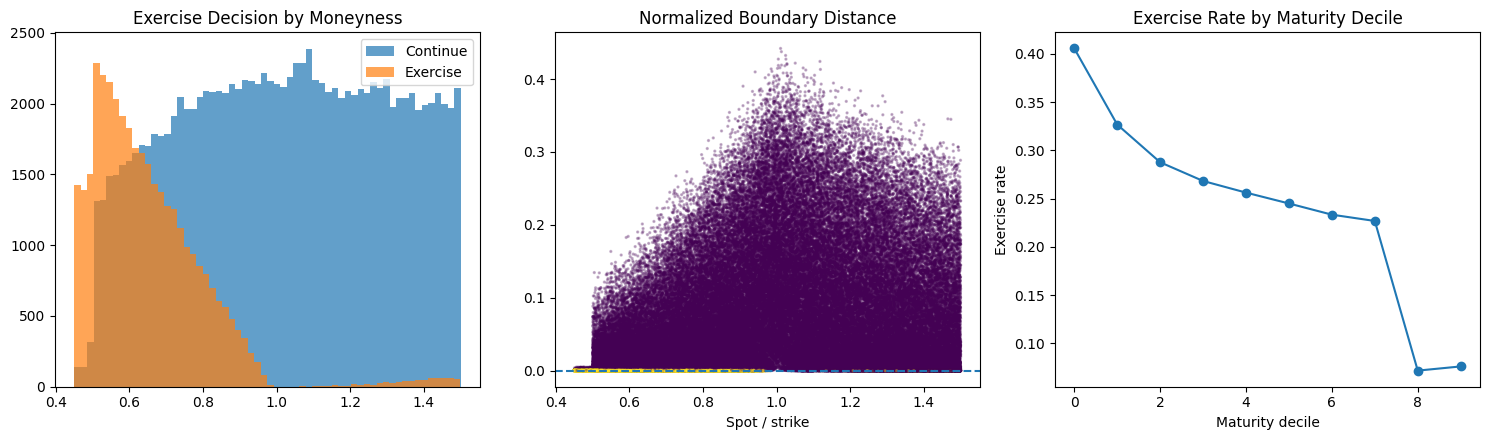

In [5]:
analysis_sample = train_frame.sample(
    min(150_000, len(train_frame)),
    random_state=SEED,
)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
axes[0].hist(
    analysis_sample.loc[~analysis_sample["exercise_now"], "moneyness"],
    bins=60,
    alpha=0.7,
    label="Continue",
)
axes[0].hist(
    analysis_sample.loc[analysis_sample["exercise_now"], "moneyness"],
    bins=60,
    alpha=0.7,
    label="Exercise",
)
axes[0].set_title("Exercise Decision by Moneyness")
axes[0].legend()

axes[1].scatter(
    analysis_sample["moneyness"],
    analysis_sample["boundary_distance_normalized"],
    c=analysis_sample["exercise_now"].astype(int),
    s=2,
    alpha=0.25,
)
axes[1].axhline(0.0, linestyle="--")
axes[1].set_title("Normalized Boundary Distance")
axes[1].set_xlabel("Spot / strike")

exercise_by_maturity = (
    analysis_sample.assign(
        maturity_bucket=pd.qcut(
            analysis_sample["time_to_maturity"],
            q=10,
            duplicates="drop",
        )
    )
    .groupby("maturity_bucket", observed=True)["exercise_now"]
    .mean()
)
axes[2].plot(range(len(exercise_by_maturity)), exercise_by_maturity.values, marker="o")
axes[2].set_title("Exercise Rate by Maturity Decile")
axes[2].set_xlabel("Maturity decile")
axes[2].set_ylabel("Exercise rate")
plt.tight_layout()
plt.show()

# 4. PyTorch input pipeline

The multi-task dataset returns one shared feature tensor together with:

- the normalized floor-residual target;
- the binary exercise target;
- normalized European, intrinsic, and American values;
- the source row identifier.

The feature scaler fitted in Notebook 04 is reused unchanged.

In [6]:
feature_scaler = load_feature_scaler(SCALER_PATH)
LOADER_CONFIG = LoaderConfig(
    batch_size=1024,
    num_workers=0,
    pin_memory=True,
    seed=SEED,
)


def make_multitask_loader(frame, *, shuffle=False, drop_last=False):
    dataset = MultiTaskAmericanOptionDataset(
        frame,
        scaler=feature_scaler,
        residual_target_column="normalized_floor_residual",
    )
    loader = create_multitask_loader(
        dataset,
        config=LOADER_CONFIG,
        shuffle=shuffle,
        drop_last=drop_last,
    )
    return dataset, loader


_, train_loader = make_multitask_loader(train_frame, shuffle=True, drop_last=True)
_, validation_loader = make_multitask_loader(validation_frame, shuffle=False)
_, test_loader = make_multitask_loader(test_frame, shuffle=False)

batch = next(iter(train_loader))
{
    key: tuple(value.shape) if isinstance(value, torch.Tensor) else type(value).__name__
    for key, value in batch.items()
}

{'features': (1024, 5),
 'residual_target': (1024, 1),
 'exercise_target': (1024, 1),
 'normalized_european': (1024, 1),
 'normalized_intrinsic': (1024, 1),
 'normalized_american': (1024, 1),
 'row_id': (1024,)}

# 5. Exercise-only classifier baseline

Before joint learning, a separate classifier is trained using the same five pricing inputs. This baseline determines whether the stopping decision is learnable independently of the price objective.

The positive-class weight is estimated only from the training split:

$$
w_+=\frac{N_{continue}}{N_{exercise}}.
$$

**Execution control.** `FORCE_TRAIN = True` retrains both the exercise-only classifier and the multi-task candidates. After a successful run, set it to `False`; each stage is checked and loaded independently, while any missing or incomplete stage is retrained automatically.


In [7]:

positive_class_weight = calculate_positive_class_weight(
    train_frame["exercise_now"]
)
CLASSIFIER_TRAINING_CONFIG = MultiTaskTrainingConfig(
    epochs=100,
    learning_rate=1e-3,
    weight_decay=1e-5,
    early_stopping_patience=10,
    scheduler_patience=4,
    mixed_precision=True,
    seed=SEED,
)

CLASSIFIER_CHECKPOINT_PATH = (
    MULTITASK_ARTIFACT_DIR / "best_exercise_classifier.pt"
)
CLASSIFIER_HISTORY_PATH = (
    MULTITASK_ARTIFACT_DIR / "exercise_classifier_history.csv"
)
CLASSIFIER_CONFIG_PATH = (
    MULTITASK_ARTIFACT_DIR / "exercise_classifier_training_config.json"
)
CLASSIFIER_MANIFEST_PATH = (
    MULTITASK_ARTIFACT_DIR / "exercise_classifier_complete.json"
)

classifier_outputs_available, classifier_availability_reason = (
    inspect_training_artifacts(
        CLASSIFIER_MANIFEST_PATH,
        [
            CLASSIFIER_CHECKPOINT_PATH,
            CLASSIFIER_HISTORY_PATH,
            CLASSIFIER_CONFIG_PATH,
        ],
        expected_notebook="06_exercise_classifier",
        expected_profile=TRAINING_PROFILE,
    )
)
RUN_CLASSIFIER_TRAINING = (
    FORCE_TRAIN or not classifier_outputs_available
)

print(f"Force training:               {FORCE_TRAIN}")
print(f"Classifier outputs available: {classifier_outputs_available}")
print(
    "Classifier decision:         "
    f"{'train' if RUN_CLASSIFIER_TRAINING else 'load'}"
)
print(f"Classifier artifact check:    {classifier_availability_reason}")

exercise_classifier = ExerciseClassifierMLP().to(DEVICE)

if RUN_CLASSIFIER_TRAINING:
    CLASSIFIER_MANIFEST_PATH.unlink(missing_ok=True)
    classifier_started = time.perf_counter()

    classifier_history = fit_exercise_classifier(
        exercise_classifier,
        train_loader,
        validation_loader,
        positive_class_weight=positive_class_weight,
        config=CLASSIFIER_TRAINING_CONFIG,
        device=DEVICE,
        checkpoint_path=CLASSIFIER_CHECKPOINT_PATH,
    )
    classifier_runtime_seconds = time.perf_counter() - classifier_started

    classifier_history.to_csv(
        CLASSIFIER_HISTORY_PATH,
        index=False,
    )
    save_json(
        CLASSIFIER_TRAINING_CONFIG.to_dict(),
        CLASSIFIER_CONFIG_PATH,
    )

    classifier_checkpoint = load_checkpoint(
        CLASSIFIER_CHECKPOINT_PATH,
        map_location="cpu",
    )
    epochs_completed = int(classifier_history["epoch"].max())

    write_training_manifest(
        CLASSIFIER_MANIFEST_PATH,
        {
            "status": "complete",
            "notebook": "06_exercise_classifier",
            "training_profile": TRAINING_PROFILE,
            "requested_epochs": int(CLASSIFIER_TRAINING_CONFIG.epochs),
            "epochs_completed": epochs_completed,
            "best_epoch": int(classifier_checkpoint["epoch"]),
            "early_stopped": (
                epochs_completed
                < int(CLASSIFIER_TRAINING_CONFIG.epochs)
            ),
            "best_validation_loss": float(
                classifier_checkpoint["validation_loss"]
            ),
            "training_runtime_seconds": float(
                classifier_runtime_seconds
            ),
            "checkpoint": CLASSIFIER_CHECKPOINT_PATH.name,
            "history": CLASSIFIER_HISTORY_PATH.name,
        },
    )
else:
    classifier_history = pd.read_csv(CLASSIFIER_HISTORY_PATH)
    classifier_checkpoint = load_checkpoint(
        CLASSIFIER_CHECKPOINT_PATH,
        map_location=DEVICE,
    )
    exercise_classifier.load_state_dict(
        classifier_checkpoint["model_state_dict"]
    )
    exercise_classifier.to(DEVICE).eval()

classifier_history.tail()


Training exercise classifier on cuda
Train batches: 854
Validation batches: 184
Positive class weight: 3.1718


Epoch 001 training:   0%|          | 0/854 [00:00<?, ?batch/s]

Epoch 001 validation:   0%|          | 0/184 [00:00<?, ?batch/s]

Epoch 001 | Train loss: 0.091112 | Train accuracy: 0.9724 | Val loss: 0.044061 | Val accuracy: 0.9866 | LR: 1.00e-03 | Time: 19.2s


Epoch 002 training:   0%|          | 0/854 [00:00<?, ?batch/s]

...

Epoch 072 | Train loss: 0.037615 | Train accuracy: 0.9884 | Val loss: 0.020620 | Val accuracy: 0.9920 | LR: 3.13e-05 | Time: 19.3s


Epoch 073 training:   0%|          | 0/854 [00:00<?, ?batch/s]

Epoch 073 validation:   0%|          | 0/184 [00:00<?, ?batch/s]

Epoch 073 | Train loss: 0.036790 | Train accuracy: 0.9886 | Val loss: 0.019624 | Val accuracy: 0.9950 | LR: 1.56e-05 | Time: 19.2s


,epoch,train_loss,validation_loss,train_accuracy,validation_accuracy,learning_rate,epoch_seconds
68,69.0,0.036511,0.019719,0.988839,0.995162,0.000031,19.320257
69,70.0,0.036294,0.019971,0.988677,0.993340,0.000031,19.179750
70,71.0,0.036568,0.020427,0.988697,0.992551,0.000031,19.228989
71,72.0,0.037615,0.020620,0.988351,0.991954,0.000031,19.275881
72,73.0,0.036790,0.019624,0.988577,0.995013,0.000016,19.162453


In [8]:
classifier_validation_predictions = predict_exercise_classifier(
    exercise_classifier,
    validation_loader,
    device=DEVICE,
)
classifier_validation = validation_frame[[
    "sample_id", "exercise_now", "boundary_distance_normalized"
]].merge(
    classifier_validation_predictions,
    on="sample_id",
    validate="one_to_one",
)
classifier_threshold_result = choose_f1_threshold(
    classifier_validation["exercise_now"],
    classifier_validation["exercise_probability"],
)
CLASSIFIER_THRESHOLD = classifier_threshold_result["threshold"]
classifier_validation_metrics = binary_classification_metrics(
    classifier_validation["exercise_now"],
    classifier_validation["exercise_probability"],
    threshold=CLASSIFIER_THRESHOLD,
)
pd.Series(classifier_validation_metrics, name="classifier validation")

observations         187677.000000
positive_rate             0.239523
threshold                 0.670000
accuracy                  0.998465
balanced_accuracy         0.998046
precision                 0.996355
recall                    0.997242
f1                        0.996798
brier_score               0.003662
roc_auc                   0.999984
pr_auc                    0.999951
Name: classifier validation, dtype: float64

# 6. Multi-task architecture and loss-weight ablation

The shared backbone feeds two heads:

```text
Input(5)
→ Shared backbone
   ├── Softplus residual-regression head
   └── Exercise-logit classification head
```

The combined objective is

$$
\mathcal{L}
=
\mathcal{L}_{price}
+
\lambda\mathcal{L}_{exercise}.
$$

Three predefined values of \(\lambda\) are compared. Selection uses only validation observations and prioritizes F1-score inside the \(|D|\leq 0.01\) boundary band, with reconstructed-price MAE as the tie-breaker.

In [10]:

LAMBDA_CANDIDATES = (0.1, 0.5, 1.0)

MULTITASK_TRAINING_CONFIG = MultiTaskTrainingConfig(
    epochs=100,
    learning_rate=1e-3,
    weight_decay=1e-5,
    early_stopping_patience=10,
    scheduler_patience=4,
    mixed_precision=True,
    seed=SEED,
)

MODEL_CONFIG = MultiTaskMLPConfig(
    input_features=len(FEATURE_COLUMNS),
    shared_hidden_sizes=(128, 128, 64),
    batch_norm_after=(0, 1),
    regression_head_sizes=(32,),
    classification_head_sizes=(32,),
    residual_softplus=True,
)

MULTITASK_MANIFEST_PATH = (
    MULTITASK_ARTIFACT_DIR / "multitask_training_complete.json"
)
MULTITASK_CONFIG_PATH = (
    MULTITASK_ARTIFACT_DIR / "multitask_training_config.json"
)
MULTITASK_MODEL_CONFIG_PATH = (
    MULTITASK_ARTIFACT_DIR / "multitask_model_config.json"
)
MULTITASK_CANDIDATE_SUMMARY_PATH = (
    MULTITASK_ARTIFACT_DIR / "candidate_training_summary.csv"
)

candidate_names = [
    f"lambda_{exercise_lambda:g}".replace(".", "p")
    for exercise_lambda in LAMBDA_CANDIDATES
]
candidate_checkpoint_paths = {
    name: MULTITASK_ARTIFACT_DIR / f"best_multitask_{name}.pt"
    for name in candidate_names
}
candidate_history_paths = {
    name: MULTITASK_ARTIFACT_DIR / f"training_history_{name}.csv"
    for name in candidate_names
}

multitask_outputs_available, multitask_availability_reason = (
    inspect_training_artifacts(
        MULTITASK_MANIFEST_PATH,
        [
            MULTITASK_CONFIG_PATH,
            MULTITASK_MODEL_CONFIG_PATH,
            MULTITASK_CANDIDATE_SUMMARY_PATH,
            *candidate_checkpoint_paths.values(),
            *candidate_history_paths.values(),
        ],
        expected_notebook="06_multitask_model",
        expected_profile=TRAINING_PROFILE,
    )
)
RUN_MULTITASK_TRAINING = (
    FORCE_TRAIN or not multitask_outputs_available
)

print(f"Multi-task outputs available: {multitask_outputs_available}")
print(
    "Multi-task decision:         "
    f"{'train' if RUN_MULTITASK_TRAINING else 'load'}"
)
print(f"Multi-task artifact check:    {multitask_availability_reason}")

candidate_results = {}
if RUN_MULTITASK_TRAINING:
    MULTITASK_MANIFEST_PATH.unlink(missing_ok=True)
candidate_progress = tqdm(
    LAMBDA_CANDIDATES,
    desc=(
        "Training multi-task candidates"
        if RUN_MULTITASK_TRAINING
        else "Loading multi-task candidates"
    ),
    unit="model",
)
multitask_started = (
    time.perf_counter()
    if RUN_MULTITASK_TRAINING
    else None
)

for exercise_lambda in candidate_progress:
    candidate_name = (
        f"lambda_{exercise_lambda:g}".replace(".", "p")
    )
    checkpoint_path = candidate_checkpoint_paths[candidate_name]
    history_path = candidate_history_paths[candidate_name]

    candidate_progress.set_description(
        (
            f"Training {candidate_name}"
            if RUN_MULTITASK_TRAINING
            else f"Loading {candidate_name}"
        )
    )

    model = MultiTaskAmericanPutMLP(MODEL_CONFIG).to(DEVICE)

    if RUN_MULTITASK_TRAINING:
        print(
            f"\n{'=' * 72}\n"
            f"Training multi-task candidate: {candidate_name}\n"
            f"Exercise-loss weight: {exercise_lambda}\n"
            f"Device: {DEVICE}\n"
            f"{'=' * 72}",
            flush=True,
        )

        loss_config = MultiTaskLossConfig(
            exercise_lambda=exercise_lambda
        )
        loss_fn = MultiTaskPricingLoss(
            config=loss_config,
            positive_class_weight=positive_class_weight,
        ).to(DEVICE)

        history = fit_multitask_model(
            model,
            train_loader,
            validation_loader,
            loss_fn=loss_fn,
            config=MULTITASK_TRAINING_CONFIG,
            device=DEVICE,
            checkpoint_path=checkpoint_path,
            model_config=MODEL_CONFIG.to_dict(),
        )
        history.to_csv(history_path, index=False)
    else:
        history = pd.read_csv(history_path)
        checkpoint = load_checkpoint(
            checkpoint_path,
            map_location=DEVICE,
        )
        model.load_state_dict(checkpoint["model_state_dict"])
        model.to(DEVICE).eval()

    validation_predictions = predict_multitask_model(
        model,
        validation_loader,
        device=DEVICE,
    )

    validation_result = validation_frame[
        [
            "sample_id",
            "exercise_now",
            "boundary_distance_normalized",
            "normalized_american_price",
        ]
    ].merge(
        validation_predictions,
        on="sample_id",
        validate="one_to_one",
    )

    threshold_result = choose_f1_threshold(
        validation_result["exercise_now"],
        validation_result["exercise_probability"],
    )
    threshold = threshold_result["threshold"]

    boundary_metrics = boundary_band_metrics(
        validation_result,
        probability_column="exercise_probability",
        bands=(0.01,),
        threshold=threshold,
        actual_price_column="normalized_american_price",
        predicted_price_column=(
            "predicted_normalized_american_price"
        ),
    ).iloc[0]

    candidate_results[candidate_name] = {
        "exercise_lambda": exercise_lambda,
        "model": model,
        "checkpoint_path": checkpoint_path,
        "threshold": threshold,
        "boundary_f1": float(boundary_metrics["f1"]),
        "boundary_price_mae": float(
            boundary_metrics["price_mae"]
        ),
        "history": history,
    }

    candidate_progress.set_postfix(
        boundary_f1=f"{boundary_metrics['f1']:.4f}",
        price_mae=f"{boundary_metrics['price_mae']:.6f}",
    )

candidate_summary = pd.DataFrame(
    {
        name: {
            "exercise_lambda": result["exercise_lambda"],
            "threshold": result["threshold"],
            "boundary_f1": result["boundary_f1"],
            "boundary_price_mae": (
                result["boundary_price_mae"]
            ),
        }
        for name, result in candidate_results.items()
    }
).T.sort_values(
    ["boundary_f1", "boundary_price_mae"],
    ascending=[False, True],
)

if RUN_MULTITASK_TRAINING:
    multitask_runtime_seconds = (
        time.perf_counter() - multitask_started
    )
    candidate_summary.to_csv(
        MULTITASK_CANDIDATE_SUMMARY_PATH
    )
    save_json(
        MULTITASK_TRAINING_CONFIG.to_dict(),
        MULTITASK_CONFIG_PATH,
    )
    save_json(
        MODEL_CONFIG.to_dict(),
        MULTITASK_MODEL_CONFIG_PATH,
    )

    write_training_manifest(
        MULTITASK_MANIFEST_PATH,
        {
            "status": "complete",
            "notebook": "06_multitask_model",
            "training_profile": TRAINING_PROFILE,
            "requested_epochs_per_candidate": int(
                MULTITASK_TRAINING_CONFIG.epochs
            ),
            "candidate_count": len(candidate_results),
            "training_runtime_seconds": float(
                multitask_runtime_seconds
            ),
            "candidates": {
                name: {
                    "exercise_lambda": float(
                        result["exercise_lambda"]
                    ),
                    "threshold": float(result["threshold"]),
                    "boundary_f1": float(result["boundary_f1"]),
                    "boundary_price_mae": float(
                        result["boundary_price_mae"]
                    ),
                    "checkpoint": result[
                        "checkpoint_path"
                    ].name,
                    "history": candidate_history_paths[name].name,
                }
                for name, result in candidate_results.items()
            },
        },
    )

candidate_summary


Multi-task candidates:   0%|          | 0/3 [00:00<?, ?model/s]


Training multi-task candidate: lambda_0p1
Exercise-loss weight: 0.1
Device: cuda


Training:   0%|          | 0/854 [00:00<?, ?batch/s]

Training:   0%|          | 0/854 [00:00<?, ?batch/s]

Training:   0%|          | 0/854 [00:00<?, ?batch/s]

...

Training:   0%|          | 0/854 [00:00<?, ?batch/s]

Training:   0%|          | 0/854 [00:00<?, ?batch/s]

Training:   0%|          | 0/854 [00:00<?, ?batch/s]

Training:   0%|          | 0/854 [00:00<?, ?batch/s]

,exercise_lambda,threshold,boundary_f1,boundary_price_mae
lambda_0p1,0.1,0.685,0.996772,0.000154
lambda_1,1.0,0.675,0.996030,0.000122
lambda_0p5,0.5,0.665,0.994872,0.000137


In [11]:
best_candidate_name = candidate_summary.index[0]
best_candidate = candidate_results[best_candidate_name]
best_multitask_model = best_candidate["model"]
MULTITASK_THRESHOLD = float(best_candidate["threshold"])
print(f"Selected candidate: {best_candidate_name}")
print(f"Exercise lambda: {best_candidate['exercise_lambda']}")
print(f"Validation threshold: {MULTITASK_THRESHOLD:.4f}")

Selected candidate: lambda_0p1
Exercise lambda: 0.1
Validation threshold: 0.6850


# 7. In-domain classification evaluation

The held-out test set is evaluated once after the validation-based model and threshold selection. Raw accuracy is reported, but balanced accuracy, F1, PR-AUC, and the confusion matrix are more informative when exercise observations are imbalanced.

In [12]:
classifier_test_predictions = predict_exercise_classifier(
    exercise_classifier,
    test_loader,
    device=DEVICE,
).rename(columns={"exercise_probability": "classifier_probability"})

multitask_test_predictions = predict_multitask_model(
    best_multitask_model,
    test_loader,
    device=DEVICE,
    classification_threshold=MULTITASK_THRESHOLD,
).rename(columns={"exercise_probability": "multitask_probability"})

test_results = test_frame.copy()
test_results = test_results.merge(
    classifier_test_predictions[["sample_id", "classifier_probability"]],
    on="sample_id",
    validate="one_to_one",
)
test_results = test_results.merge(
    multitask_test_predictions[
        [
            "sample_id",
            "predicted_residual",
            "predicted_normalized_american_price",
            "multitask_probability",
        ]
    ],
    on="sample_id",
    validate="one_to_one",
)

classification_comparison = pd.DataFrame(
    {
        "Exercise-only classifier": binary_classification_metrics(
            test_results["exercise_now"],
            test_results["classifier_probability"],
            threshold=CLASSIFIER_THRESHOLD,
        ),
        "Multi-task model": binary_classification_metrics(
            test_results["exercise_now"],
            test_results["multitask_probability"],
            threshold=MULTITASK_THRESHOLD,
        ),
    }
).T
classification_comparison

,observations,positive_rate,threshold,accuracy,balanced_accuracy,precision,recall,f1,brier_score,roc_auc,pr_auc
Exercise-only classifier,187811.0,0.240454,0.670,0.998264,0.997874,0.995666,0.997121,0.996393,0.003694,0.999982,0.999946
Multi-task model,187811.0,0.240454,0.685,0.998264,0.997344,0.997205,0.995571,0.996388,0.003922,0.999979,0.999934


In [13]:
confusion_matrix_frame(
    test_results["exercise_now"],
    test_results["multitask_probability"],
    threshold=MULTITASK_THRESHOLD,
)

prediction,predicted_continue,predicted_exercise
actual,,
actual_continue,142525,126
actual_exercise,200,44960


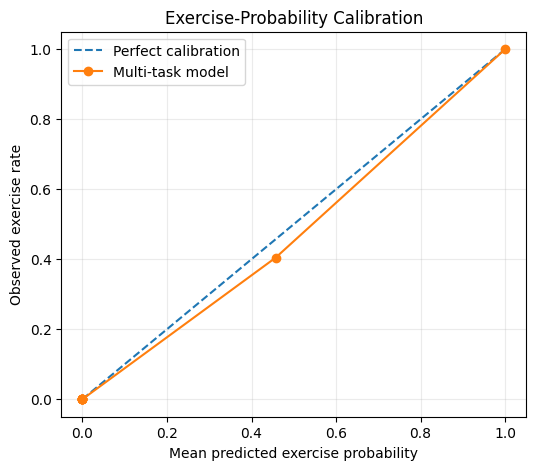

In [14]:
calibration = calibration_frame(
    test_results["exercise_now"],
    test_results["multitask_probability"],
    bins=10,
)
plt.figure(figsize=(6, 5))
plt.plot([0, 1], [0, 1], linestyle="--", label="Perfect calibration")
plt.plot(
    calibration["mean_predicted_probability"],
    calibration["observed_exercise_rate"],
    marker="o",
    label="Multi-task model",
)
plt.xlabel("Mean predicted exercise probability")
plt.ylabel("Observed exercise rate")
plt.title("Exercise-Probability Calibration")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

# 8. Boundary-focused evaluation

The normalized distance

$$
D=\frac{I-C}{K}
$$

has a direct economic interpretation:

- \(D>0\): exercise region;
- \(D<0\): continuation region;
- \(D\approx 0\): exercise boundary.

Performance is evaluated in progressively wider bands around zero. This prevents strong results in easy regions from concealing errors at the actual stopping frontier.

In [15]:
classifier_boundary_metrics = boundary_band_metrics(
    test_results,
    probability_column="classifier_probability",
    bands=(0.001, 0.005, 0.010),
    threshold=CLASSIFIER_THRESHOLD,
)
classifier_boundary_metrics.insert(0, "model", "Exercise-only classifier")

multitask_boundary_metrics = boundary_band_metrics(
    test_results,
    probability_column="multitask_probability",
    bands=(0.001, 0.005, 0.010),
    threshold=MULTITASK_THRESHOLD,
    actual_price_column="normalized_american_price",
    predicted_price_column="predicted_normalized_american_price",
)
multitask_boundary_metrics.insert(0, "model", "Multi-task model")

boundary_comparison = pd.concat(
    [classifier_boundary_metrics, multitask_boundary_metrics],
    ignore_index=True,
)
boundary_comparison

,model,boundary_band,observations,accuracy,balanced_accuracy,precision,recall,f1,false_exercise_rate,missed_exercise_rate,price_mae
0,Exercise-only classifier,0.001,59673.0,0.994537,0.991808,0.995666,0.997121,0.996393,0.013505,0.002879,NaN
1,Exercise-only classifier,0.005,73673.0,0.995575,0.995124,0.995666,0.997121,0.996393,0.006874,0.002879,NaN
2,Exercise-only classifier,0.010,80785.0,0.995965,0.995810,0.995666,0.997121,0.996393,0.005502,0.002879,NaN
3,Multi-task model,0.001,59673.0,0.994537,0.993445,0.997205,0.995571,0.996388,0.008682,0.004429,0.000081
4,Multi-task model,0.005,73673.0,0.995575,0.995576,0.997205,0.995571,0.996388,0.004419,0.004429,0.000131
5,Multi-task model,0.010,80785.0,0.995965,0.996017,0.997205,0.995571,0.996388,0.003537,0.004429,0.000151


# 9. Step 5 price-only comparison

The best Step 5 constrained residual model provides the price-only benchmark. Its boundary-region price error is compared with the multi-task model using the same test observations.

In [16]:
with PREMIUM_SUMMARY_PATH.open("r", encoding="utf-8") as file:
    premium_summary = json.load(file)
best_floor_candidate = premium_summary["best_floor_candidate"]
premium_checkpoint_path = PREMIUM_ARTIFACT_DIR / f"best_{best_floor_candidate}.pt"
if not premium_checkpoint_path.exists():
    raise FileNotFoundError(premium_checkpoint_path)

premium_checkpoint = load_checkpoint(premium_checkpoint_path, map_location=DEVICE)
raw_config = premium_checkpoint["model_config"]
premium_model_config = PremiumMLPConfig(
    input_features=int(raw_config["input_features"]),
    hidden_sizes=tuple(raw_config["hidden_sizes"]),
    batch_norm_after=tuple(raw_config["batch_norm_after"]),
    output_activation=raw_config["output_activation"],
    residual_base=raw_config["residual_base"],
)
price_only_model = PremiumAmericanPutMLP(premium_model_config).to(DEVICE)
price_only_model.load_state_dict(premium_checkpoint["model_state_dict"])

from src.data.torch_datasets import AmericanOptionDataset, create_regression_loader

price_only_dataset = AmericanOptionDataset(
    test_frame,
    scaler=feature_scaler,
    target_column="normalized_floor_residual",
)
price_only_loader = create_regression_loader(
    price_only_dataset,
    config=LOADER_CONFIG,
    shuffle=False,
)
price_only_residual = predict_regression_model(
    price_only_model,
    price_only_loader,
    device=DEVICE,
).rename(columns={"prediction": "price_only_residual"})
test_results = test_results.merge(
    price_only_residual,
    on="sample_id",
    validate="one_to_one",
)
test_results["price_only_normalized_price"] = (
    test_results["normalized_financial_floor"]
    + test_results["price_only_residual"]
)

price_metrics = pd.DataFrame(
    {
        "Price-only constrained residual": regression_metrics(
            test_results["normalized_american_price"],
            test_results["price_only_normalized_price"],
        ),
        "Multi-task constrained residual": regression_metrics(
            test_results["normalized_american_price"],
            test_results["predicted_normalized_american_price"],
        ),
    }
).T
price_metrics

,observations,mae,rmse,median_absolute_error,max_absolute_error,mean_error,r2,within_0.001,within_0.005,within_0.01,within_0.05
Price-only constrained residual,187811.0,0.000102,0.000213,0.000046,0.004641,-1.426903e-05,0.999998,0.992860,1.000000,1.000000,1.0
Multi-task constrained residual,187811.0,0.000242,0.000504,0.000082,0.010295,1.801177e-07,0.999990,0.952404,0.999287,0.999989,1.0


In [17]:
price_boundary_rows = []
for model_name, prediction_column in {
    "Price-only constrained residual": "price_only_normalized_price",
    "Multi-task constrained residual": "predicted_normalized_american_price",
}.items():
    for band in (0.001, 0.005, 0.010):
        subset = test_results.loc[
            test_results["boundary_distance_normalized"].abs() <= band
        ]
        metrics = regression_metrics(
            subset["normalized_american_price"],
            subset[prediction_column],
        )
        price_boundary_rows.append(
            {"model": model_name, "boundary_band": band, **metrics}
        )
price_boundary_comparison = pd.DataFrame(price_boundary_rows)
price_boundary_comparison

,model,boundary_band,observations,mae,rmse,median_absolute_error,max_absolute_error,mean_error,r2,within_0.001,within_0.005,within_0.01,within_0.05
0,Price-only constrained residual,0.001,59673.0,0.000052,0.000138,7.811337e-07,0.002193,0.000048,0.999999,0.998576,1.000000,1.0,1.0
1,Price-only constrained residual,0.005,73673.0,0.000073,0.000186,3.154947e-06,0.003286,0.000033,0.999999,0.994421,1.000000,1.0,1.0
2,Price-only constrained residual,0.010,80785.0,0.000079,0.000199,4.914575e-06,0.003586,0.000027,0.999999,0.993353,1.000000,1.0,1.0
3,Multi-task constrained residual,0.001,59673.0,0.000081,0.000231,1.129937e-06,0.004630,0.000075,0.999998,0.988403,1.000000,1.0,1.0
4,Multi-task constrained residual,0.005,73673.0,0.000131,0.000334,4.255015e-06,0.004771,0.000059,0.999997,0.972134,1.000000,1.0,1.0
5,Multi-task constrained residual,0.010,80785.0,0.000151,0.000384,6.587352e-06,0.006084,0.000051,0.999996,0.963360,0.999889,1.0,1.0


# 10. Exercise-boundary reconstruction

For fixed values of maturity, rates, dividends, and volatility, the CRR engine and neural classifiers are evaluated across a dense moneyness grid. The boundary is the point where exercise probability crosses the selected classification threshold.

The neural boundary is not assumed to exist for every slice. Missing crossings are reported as missing coverage rather than silently extrapolated.

In [18]:
def build_boundary_slice(
    *,
    time_to_maturity,
    risk_free_rate,
    dividend_yield,
    volatility,
    strike=100.0,
    steps=250,
    points=241,
):
    moneyness_grid = np.linspace(0.40, 1.20, points)
    rows = []
    for moneyness in moneyness_grid:
        spot = strike * moneyness
        diagnostic = crr_option_diagnostics(
            spot=spot,
            strike=strike,
            time_to_maturity=time_to_maturity,
            risk_free_rate=risk_free_rate,
            dividend_yield=dividend_yield,
            volatility=volatility,
            steps=steps,
            option_type="put",
            exercise_style="american",
        )
        european = black_scholes_put_price(
            spot=spot,
            strike=strike,
            time_to_maturity=time_to_maturity,
            risk_free_rate=risk_free_rate,
            dividend_yield=dividend_yield,
            volatility=volatility,
        )
        intrinsic = max(strike - spot, 0.0)
        floor = max(european, intrinsic)
        rows.append(
            {
                "moneyness": moneyness,
                "log_moneyness": np.log(moneyness),
                "time_to_maturity": time_to_maturity,
                "risk_free_rate": risk_free_rate,
                "dividend_yield": dividend_yield,
                "volatility": volatility,
                "exercise_now": diagnostic.exercise_now,
                "normalized_european_price": european / strike,
                "normalized_intrinsic_value": intrinsic / strike,
                "normalized_financial_floor": floor / strike,
                "normalized_american_price": diagnostic.price / strike,
                "normalized_floor_residual": max(diagnostic.price - floor, 0.0) / strike,
            }
        )
    frame = pd.DataFrame(rows)
    values = feature_scaler.transform(frame.loc[:, FEATURE_COLUMNS]).astype(np.float32)
    features = torch.from_numpy(values).to(DEVICE)
    with torch.inference_mode():
        classifier_probability = torch.sigmoid(
            exercise_classifier(features)
        ).cpu().numpy().reshape(-1)
        residual, logits = best_multitask_model(features)
        multitask_probability = torch.sigmoid(logits).cpu().numpy().reshape(-1)
    frame["classifier_probability"] = classifier_probability
    frame["multitask_probability"] = multitask_probability
    return frame


BOUNDARY_SLICES = [
    {"time_to_maturity": 0.25, "risk_free_rate": 0.03, "dividend_yield": 0.01, "volatility": 0.20},
    {"time_to_maturity": 0.50, "risk_free_rate": 0.05, "dividend_yield": 0.01, "volatility": 0.25},
    {"time_to_maturity": 1.00, "risk_free_rate": 0.07, "dividend_yield": 0.02, "volatility": 0.30},
    {"time_to_maturity": 1.50, "risk_free_rate": 0.09, "dividend_yield": 0.03, "volatility": 0.40},
]

boundary_rows = []
boundary_frames = []
for slice_id, specification in enumerate(BOUNDARY_SLICES):
    frame = build_boundary_slice(**specification)
    frame["slice_id"] = slice_id
    boundary_frames.append(frame)
    actual = extract_label_boundary(frame["moneyness"], frame["exercise_now"])
    classifier = extract_probability_boundary(
        frame["moneyness"],
        frame["classifier_probability"],
        threshold=CLASSIFIER_THRESHOLD,
    )
    multitask = extract_probability_boundary(
        frame["moneyness"],
        frame["multitask_probability"],
        threshold=MULTITASK_THRESHOLD,
    )
    boundary_rows.append(
        {
            "slice_id": slice_id,
            **specification,
            "crr_boundary": actual.boundary_moneyness,
            "classifier_boundary": classifier.boundary_moneyness,
            "multitask_boundary": multitask.boundary_moneyness,
        }
    )

boundary_curves = pd.DataFrame(boundary_rows)
boundary_grid = pd.concat(boundary_frames, ignore_index=True)
boundary_curves

/usr/local/lib/python3.10/dist-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


,slice_id,time_to_maturity,risk_free_rate,dividend_yield,volatility,crr_boundary,classifier_boundary,multitask_boundary
0,0,0.25,0.03,0.01,0.20,0.838333,0.837977,0.837737
1,1,0.50,0.05,0.01,0.25,0.781667,0.780875,0.781928
2,2,1.00,0.07,0.02,0.30,0.705000,0.706704,0.706660
3,3,1.50,0.09,0.03,0.40,0.598333,0.599950,0.599705


In [19]:
classifier_boundary_error = boundary_location_error(
    boundary_curves["crr_boundary"],
    boundary_curves["classifier_boundary"],
)
multitask_boundary_error = boundary_location_error(
    boundary_curves["crr_boundary"],
    boundary_curves["multitask_boundary"],
)
pd.DataFrame(
    {
        "Exercise-only classifier": classifier_boundary_error,
        "Multi-task model": multitask_boundary_error,
    }
).T

,slices,valid_slices,coverage,boundary_mae,boundary_max_error
Exercise-only classifier,4.0,4.0,1.0,0.001117,0.001704
Multi-task model,4.0,4.0,1.0,0.000972,0.001660


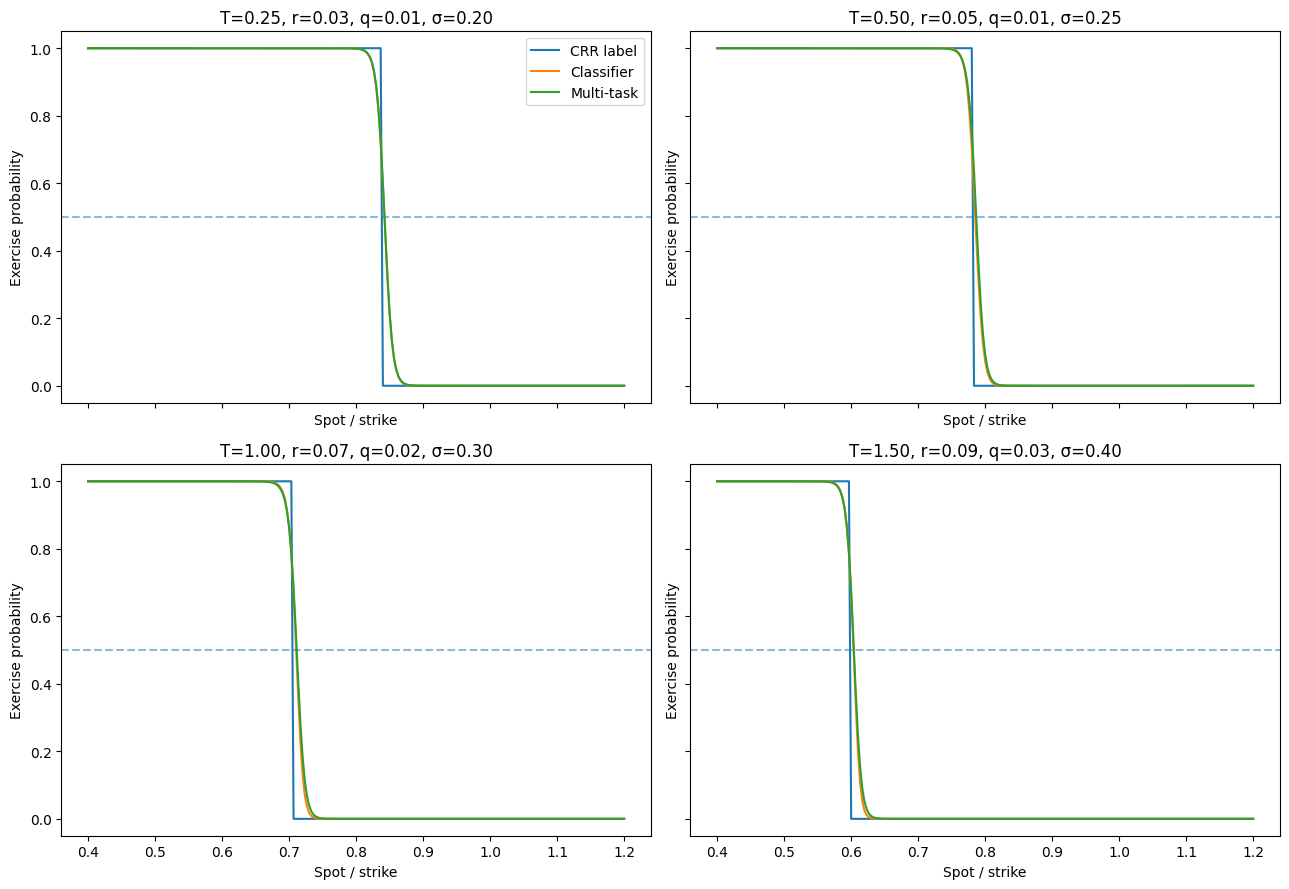

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9), sharex=True, sharey=True)
for axis, (slice_id, frame) in zip(axes.ravel(), boundary_grid.groupby("slice_id")):
    row = boundary_curves.loc[boundary_curves["slice_id"] == slice_id].iloc[0]
    axis.plot(frame["moneyness"], frame["exercise_now"].astype(float), label="CRR label")
    axis.plot(frame["moneyness"], frame["classifier_probability"], label="Classifier")
    axis.plot(frame["moneyness"], frame["multitask_probability"], label="Multi-task")
    axis.axhline(0.5, linestyle="--", alpha=0.5)
    axis.set_title(
        f"T={row.time_to_maturity:.2f}, r={row.risk_free_rate:.2f}, "
        f"q={row.dividend_yield:.2f}, σ={row.volatility:.2f}"
    )
    axis.set_xlabel("Spot / strike")
    axis.set_ylabel("Exercise probability")
axes[0, 0].legend()
plt.tight_layout()
plt.show()

# 11. Boundary monotonicity diagnostics

The learned boundary should respond economically to the conditioning variables, but no monotonic relationship is hard-coded. The project therefore reports observed violations rather than assuming the network has learned a stable free-boundary surface.

The direction of the theoretical response can depend on which variables are held fixed. These checks are treated as diagnostics, not universal proofs.

In [21]:
monotonicity_rows = []
for parameter, direction in {
    "time_to_maturity": "decreasing",
    "risk_free_rate": "increasing",
    "volatility": "decreasing",
}.items():
    monotonicity_rows.append(
        {
            "parameter": parameter,
            "expected_direction": direction,
            **boundary_monotonicity_report(
                boundary_curves,
                parameter_column=parameter,
                boundary_column="multitask_boundary",
                expected_direction=direction,
            ),
        }
    )
pd.DataFrame(monotonicity_rows)

,parameter,expected_direction,comparisons,violations,violation_rate
0,time_to_maturity,decreasing,3.0,0.0,0.0
1,risk_free_rate,increasing,3.0,3.0,1.0
2,volatility,decreasing,3.0,0.0,0.0


# 12. Out-of-domain evaluation

The exercise classifier and multi-task network are evaluated on all four out-of-domain components. Classification may deteriorate more sharply than price regression because the learned boundary is sensitive to parameter combinations absent from training.

In [22]:
ood_rows = []
for ood_name, path in OOD_PATHS.items():
    frame = read_parquet_components([path], columns=MODEL_COLUMNS, split=None)
    frame["normalized_intrinsic_value"] = frame["intrinsic_value"] / frame["strike"]
    frame["normalized_financial_floor"] = np.maximum(
        frame["normalized_european_price"], frame["normalized_intrinsic_value"]
    )
    frame["normalized_floor_residual"] = (
        frame["normalized_american_price"] - frame["normalized_financial_floor"]
    ).clip(lower=0.0)
    _, loader = make_multitask_loader(frame, shuffle=False)
    classifier_predictions = predict_exercise_classifier(
        exercise_classifier, loader, device=DEVICE
    ).rename(columns={"exercise_probability": "classifier_probability"})
    multitask_predictions = predict_multitask_model(
        best_multitask_model,
        loader,
        device=DEVICE,
        classification_threshold=MULTITASK_THRESHOLD,
    ).rename(columns={"exercise_probability": "multitask_probability"})
    result = frame.merge(
        classifier_predictions[["sample_id", "classifier_probability"]],
        on="sample_id",
        validate="one_to_one",
    ).merge(
        multitask_predictions[[
            "sample_id", "multitask_probability",
            "predicted_normalized_american_price",
        ]],
        on="sample_id",
        validate="one_to_one",
    )
    for model_name, probability_column, threshold in (
        ("Exercise-only classifier", "classifier_probability", CLASSIFIER_THRESHOLD),
        ("Multi-task model", "multitask_probability", MULTITASK_THRESHOLD),
    ):
        ood_rows.append(
            {
                "ood_set": ood_name,
                "model": model_name,
                **binary_classification_metrics(
                    result["exercise_now"],
                    result[probability_column],
                    threshold=threshold,
                ),
            }
        )
    price_row = {
        "ood_set": ood_name,
        "model": "Multi-task price",
        **regression_metrics(
            result["normalized_american_price"],
            result["predicted_normalized_american_price"],
        ),
    }
    ood_rows.append(price_row)

ood_results = pd.DataFrame(ood_rows)
ood_results

,ood_set,model,observations,positive_rate,threshold,accuracy,balanced_accuracy,precision,recall,f1,...,mae,rmse,median_absolute_error,max_absolute_error,mean_error,r2,within_0.001,within_0.005,within_0.01,within_0.05
0,high_volatility,Exercise-only classifier,50000.0,0.00244,0.670,0.99820,0.982744,0.578431,0.967213,0.723926,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,high_volatility,Multi-task model,50000.0,0.00244,0.685,0.99860,0.962503,0.649425,0.926230,0.763514,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,high_volatility,Multi-task price,50000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.002213,0.004296,0.000842,0.047633,-0.000636,0.999105,0.53838,0.87354,0.95764,1.00000
3,extreme_moneyness,Exercise-only classifier,50000.0,0.36468,0.670,0.98390,0.980648,0.986980,0.968630,0.977719,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,extreme_moneyness,Multi-task model,50000.0,0.36468,0.685,0.98840,0.986841,0.987034,0.981079,0.984048,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,extreme_moneyness,Multi-task price,50000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.000400,0.001614,0.000003,0.036079,0.000050,0.999971,0.90910,0.98508,0.99418,1.00000
6,long_maturity,Exercise-only classifier,50000.0,0.06652,0.670,0.92898,0.940738,0.482885,0.954299,0.641277,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,long_maturity,Multi-task model,50000.0,0.06652,0.685,0.90698,0.946546,0.416404,0.992183,0.586615,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,long_maturity,Multi-task price,50000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.013689,0.030401,0.002868,0.415352,0.001258,0.963880,0.38094,0.57354,0.67902,0.93122
9,rate_dividend,Exercise-only classifier,50000.0,0.16920,0.670,0.98616,0.984517,0.938969,0.982033,0.960018,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# 13. Formal H4 decision

The predefined decision rule requires the multi-task model to improve both:

1. exercise F1 in the \(|D|\leq 0.01\) boundary band; and
2. price MAE in the same band relative to the price-only constrained residual model.

Meeting only one threshold results in partial support.

In [23]:
classifier_band_f1 = float(
    classifier_boundary_metrics.loc[
        np.isclose(classifier_boundary_metrics["boundary_band"], 0.01), "f1"
    ].iloc[0]
)
multitask_band_f1 = float(
    multitask_boundary_metrics.loc[
        np.isclose(multitask_boundary_metrics["boundary_band"], 0.01), "f1"
    ].iloc[0]
)
price_only_band_mae = float(
    price_boundary_comparison.loc[
        (price_boundary_comparison["model"] == "Price-only constrained residual")
        & np.isclose(price_boundary_comparison["boundary_band"], 0.01),
        "mae",
    ].iloc[0]
)
multitask_band_mae = float(
    price_boundary_comparison.loc[
        (price_boundary_comparison["model"] == "Multi-task constrained residual")
        & np.isclose(price_boundary_comparison["boundary_band"], 0.01),
        "mae",
    ].iloc[0]
)

h4_decision = decide_h4_multitask_learning(
    classifier_boundary_f1=classifier_band_f1,
    multitask_boundary_f1=multitask_band_f1,
    price_only_boundary_mae=price_only_band_mae,
    multitask_boundary_mae=multitask_band_mae,
)
h4_decision.to_dict()

{'hypothesis': 'H4 — Multi-task exercise learning',
 'decision': 'not supported',
 'rationale': 'The multi-task model does not meet either improvement threshold.',
 'evidence': {'classifier_boundary_f1': 0.996393246741752,
  'multitask_boundary_f1': 0.9963876515302618,
  'price_only_boundary_mae': 7.88311317148345e-05,
  'multitask_boundary_mae': 0.000151298941085007,
  'boundary_f1_improvement': -5.595211490239116e-06,
  'boundary_mae_relative_improvement': -0.9192790689891294,
  'required_f1_improvement': 0.01,
  'required_mae_improvement': 0.01}}

# 14. Save artifacts

The selected model, validation selection, test metrics, boundary curves, and formal hypothesis decision are saved for the final consolidated evaluation in Notebook 08.

In [24]:
classification_comparison.to_csv(
    MULTITASK_ARTIFACT_DIR / "classification_metrics.csv"
)
boundary_comparison.to_csv(
    MULTITASK_ARTIFACT_DIR / "boundary_metrics.csv",
    index=False,
)
price_metrics.to_csv(MULTITASK_ARTIFACT_DIR / "price_metrics.csv")
price_boundary_comparison.to_csv(
    MULTITASK_ARTIFACT_DIR / "boundary_price_metrics.csv",
    index=False,
)
boundary_curves.to_parquet(
    MULTITASK_ARTIFACT_DIR / "boundary_curves.parquet",
    index=False,
)
ood_results.to_csv(MULTITASK_ARTIFACT_DIR / "ood_results.csv", index=False)
save_json(h4_decision.to_dict(), MULTITASK_ARTIFACT_DIR / "hypothesis_decision.json")
save_json(
    {
        "selected_candidate": best_candidate_name,
        "exercise_lambda": float(best_candidate["exercise_lambda"]),
        "classifier_threshold": float(CLASSIFIER_THRESHOLD),
        "multitask_threshold": float(MULTITASK_THRESHOLD),
        "positive_class_weight": float(positive_class_weight),
        "fast_dev_mode": FAST_DEV_MODE,
        "model_config": MODEL_CONFIG.to_dict(),
    },
    MULTITASK_ARTIFACT_DIR / "evaluation_summary.json",
)
print(f"Artifacts saved to: {MULTITASK_ARTIFACT_DIR}")

Artifacts saved to: /storage/deep_learning_american_option_pricing/artifacts/multitask_model


# 15. Interpretation framework

The final interpretation should distinguish three questions:

1. **Is the exercise decision learnable?**  
   This is answered by the exercise-only classifier.

2. **Does joint learning improve boundary decisions?**  
   This is answered by boundary-band F1 and reconstructed boundary error.

3. **Does classification supervision improve pricing where it matters most?**  
   This is answered by price MAE near the exercise boundary relative to the Step 5 price-only constrained model.

A strong aggregate price result does not compensate for systematic stopping errors. Conversely, improved classification is not sufficient if joint training materially damages pricing accuracy.

# 16. Limitations

- Exercise labels are produced by a finite CRR tree and inherit its discretization error.
- Root-node classification does not represent the complete future stopping policy along every simulated path.
- Boundary class imbalance can make threshold-dependent metrics unstable.
- The selected probability threshold is validation-specific and may shift out of domain.
- The reconstructed boundary uses fixed parameter slices and does not prove global monotonicity.
- Constant volatility and continuous dividends remain material simplifications.
- Multi-task gains may depend on the chosen loss weight and shared-backbone capacity.

# 17. References used in this notebook

Cox, J. C., Ross, S. A., & Rubinstein, M. (1979). Option pricing: A simplified approach. *Journal of Financial Economics, 7*(3), 229–263.

Longstaff, F. A., & Schwartz, E. S. (2001). Valuing American options by simulation: A simple least-squares approach. *Review of Financial Studies, 14*(1), 113–147.

Pu, V. R. H. (2021). *Pricing options using deep neural networks from a practical perspective* [Master’s thesis, Imperial College London].

Zouaoui, H., & Naas, M.-N. (2023). Option pricing using deep learning approach based on LSTM-GRU neural networks. *Data Science in Finance and Economics, 3*(3), 267–284.

# 18. Development checkpoint

Notebook 06 completes the explicit exercise-boundary stage. The next step is the classical and neural Longstaff–Schwartz extension:

```text
07_neural_longstaff_schwartz.ipynb
```

That stage will move from static root-node surrogate pricing to path simulation and continuation-value estimation.